In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import pandas as pd
import geopandas as gpd
# Allow more columns to be displayed
pd.set_option("display.max_columns", None)

import logging
logging.basicConfig(level=logging.WARNING)

In [7]:
# Allow imports from parent directory
import sys
sys.path.append('..')
from utils.flood_request_utils import (
    # Hazard
    get_wri_and_si_hazard_data,
    plot_wri_and_si_hazard_data,

    # Vulnerability
    plot_wri_and_si_vulnerability_data,
    apply_damage_fraction,
    get_damage_fraction
)

In [8]:
!which python

/Users/klemenkubelj/miniconda3/envs/cvar-masters/bin/python


In [9]:
DATA_DIR = "../data"

In [10]:
vloge_df = pd.read_csv(os.path.join(DATA_DIR, "vloge_processed.csv"))
vloge_df.shape

(7090, 13)

In [11]:
vloge_df.head()

,VlogaId,ZapStev,Objekt_Naslov,Objekt_Naslov_PostnaStevilka,Objekt_Parcela_Stevilka,Objekt_Parcela_KoId,Objekt_UporabnaPovrsina,Objekt_VisinaVodeCm,Vrednost,Skoda,relative_damage,gps_lat,gps_lng
0,1229319,172,Selovec 56,2373 Šentjanž pri Dravogradu,7/5,843,51.8,170.0,11603.059650,3480.92,0.3,46.570076,15.021343
1,1229346,179,Otiški Vrh 26,2373 Šentjanž pri Dravogradu,1276/2,840,NaN,100.0,7111.540800,2133.46,0.3,46.573583,15.022361
2,1229780,96,Center 142,2393 Črna na Koroškem,168/3,906,1473.5,60.0,NaN,NaN,NaN,46.468337,14.855620
3,1229823,80,Prod 15,3333 Ljubno ob Savinji,596,923,160.0,20.0,NaN,NaN,NaN,46.341100,14.834092
4,1229889,66,Kocbekova cesta 2A,3342 Gornji Grad,22/3,942,65.5,380.0,69075.653908,34537.83,0.5,46.296753,14.806738


In [12]:
def calc_predicted_flood_depth(row):
    # Get the hazard data
    gps = {
        "lat": row["gps_lat"],
        "lng": row["gps_lng"]
    }
    data, request = get_wri_and_si_hazard_data(gps)
    return (
        data["flood_depths"]["wri"][100],
        data["flood_depths"]["si"][100],
        data["flood_depths"]["si_old"][100],
        data["damage_fractions"]["wri"][100],
        data["damage_fractions"]["si"][100],
        data["damage_fractions"]["si_old"][100]
    )

_df = vloge_df.copy()
_df["predicted_wri_depth"], _df["predicted_si_depth"], _df["predicted_si_old_depth"], _df["predicted_wri_damage"], _df["predicted_si_damage"], _df["predicted_si_old_damage"]  = zip(*_df.apply(calc_predicted_flood_depth, axis=1))

In [13]:
_df.tail()

,VlogaId,ZapStev,Objekt_Naslov,Objekt_Naslov_PostnaStevilka,Objekt_Parcela_Stevilka,Objekt_Parcela_KoId,Objekt_UporabnaPovrsina,Objekt_VisinaVodeCm,Vrednost,Skoda,relative_damage,gps_lat,gps_lng,predicted_wri_depth,predicted_si_depth,predicted_si_old_depth,predicted_wri_damage,predicted_si_damage,predicted_si_old_damage
7085,1456760,300,Gostičeva cesta 69,1235 Radomlje,165/15,1937,270.0,250.0,NaN,NaN,NaN,46.183772,14.598171,0.0,0.0,0.0,0.0,0.00,0.0
7086,1456814,934,Spodnje Javorje 8,2393 Črna na Koroškem,882/33,908,433.7,30.0,100483.240176,30144.97,0.3,46.465176,14.862976,0.0,0.0,0.0,0.0,0.00,0.0
7087,1456818,756,Otiški Vrh 139,2373 Šentjanž pri Dravogradu,1196/49,840,111.0,5.0,NaN,NaN,NaN,46.566706,15.039691,0.0,1.5,0.0,0.0,0.50,0.0
7088,1456819,496,Šentjanž 51,3332 Rečica ob Savinji,264/5,932,115.0,NaN,52447.378725,10489.48,0.2,46.314979,14.889495,0.0,0.5,0.0,0.0,0.25,0.0
7089,1456820,670,Poljane nad Škofjo Loko 77,4223 Poljane nad Škofjo Loko,*234,2047,NaN,150.0,NaN,NaN,NaN,46.121959,14.184979,0.0,0.0,0.0,0.0,0.00,0.0


(0.0, 200.0)

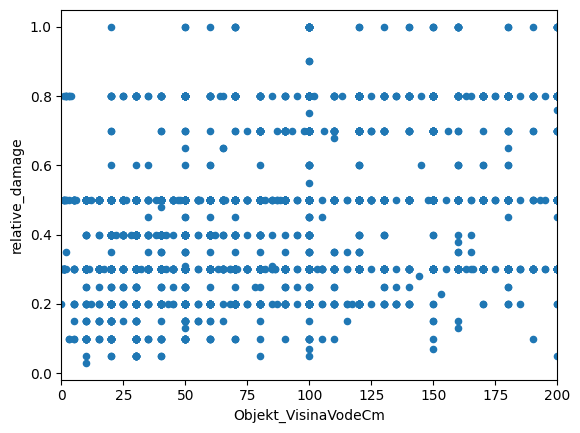

In [14]:
from matplotlib import pyplot as plt
_df.plot(x="Objekt_VisinaVodeCm", y="relative_damage", kind="scatter")
plt.xlim(0, 200)

In [15]:
import numpy as np

In [66]:
bucket_edges

array([0. , 0.5, 1. , 1.5, 2. , 2.5])

In [67]:
labels

['0m', '0.0-0.5m', '0.5-1.0m', '1.0-1.5m', '1.5-2.0m']

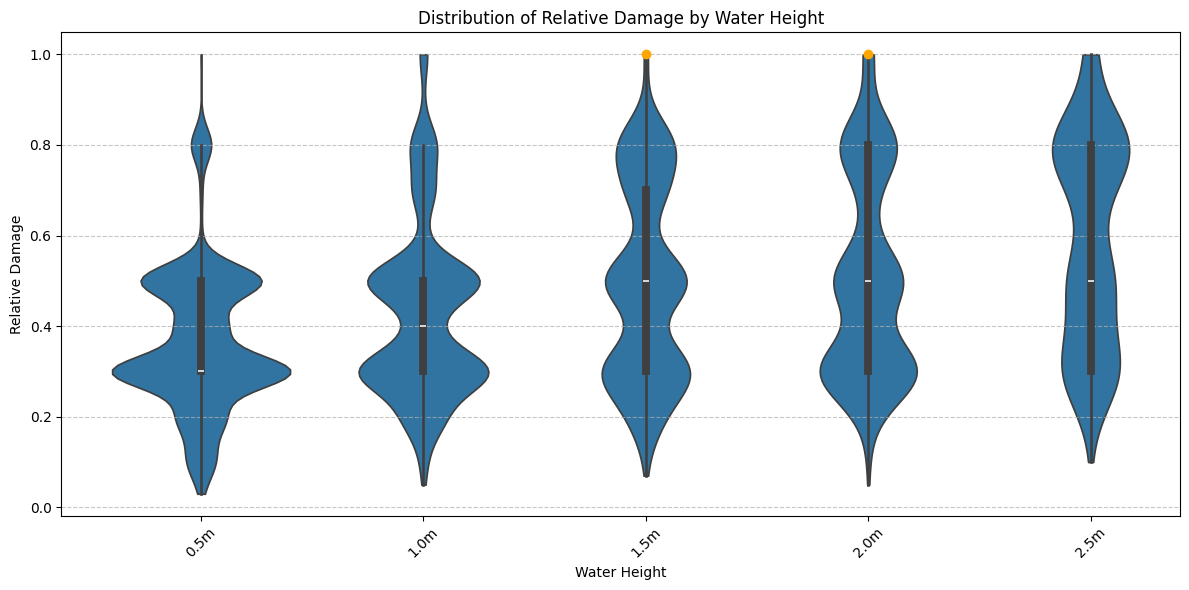

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

_df["Objekt_VisinaVodeM"] = _df["Objekt_VisinaVodeCm"]/100
# Create water height buckets (every 50cm up to 200cm)
bucket_edges = np.arange(0, 2.51, 0.5)
labels = [f"{edge}m" for edge in bucket_edges[1:]]
_df["water_height_bucket"] = pd.cut(
    _df["Objekt_VisinaVodeM"], 
    bins=bucket_edges,
    labels=labels
)

# Create the violin plot
plt.figure(figsize=(12, 6))

# Plot violins
ax = sns.violinplot(
    data=_df,
    x="water_height_bucket",
    y="relative_damage",
    cut=0  # limit the violin plot to actual data range
)

# Customize the plot
plt.title("Distribution of Relative Damage by Water Height")
plt.xlabel("Water Height")
plt.ylabel("Relative Damage")

# Set x-tick positions to match actual water heights
positions = range(len(bucket_edges[1:]))
bucket_values = bucket_edges[1:]
plt.xticks(positions, [f"{x}m" for x in bucket_values], rotation=45)

def water_height_to_position(height):
    # Find which bucket the height falls into
    for i, (lower, upper) in enumerate(zip(bucket_edges[:-1], bucket_edges[1:])):
        if lower <= height <= upper:
            return i
    return None

# Add grid for better readability
plt.grid(True, axis="y", linestyle="--", alpha=0.7)

# Now you can plot points using the water_height_to_position function
plt.plot(water_height_to_position(2.0), 1, "o", color="orange")  # This will plot at (2.0m, 1)
plt.plot(water_height_to_position(1.5), 1, "o", color="orange")  # This will plot at (2.0m, 1)
plt.tight_layout()

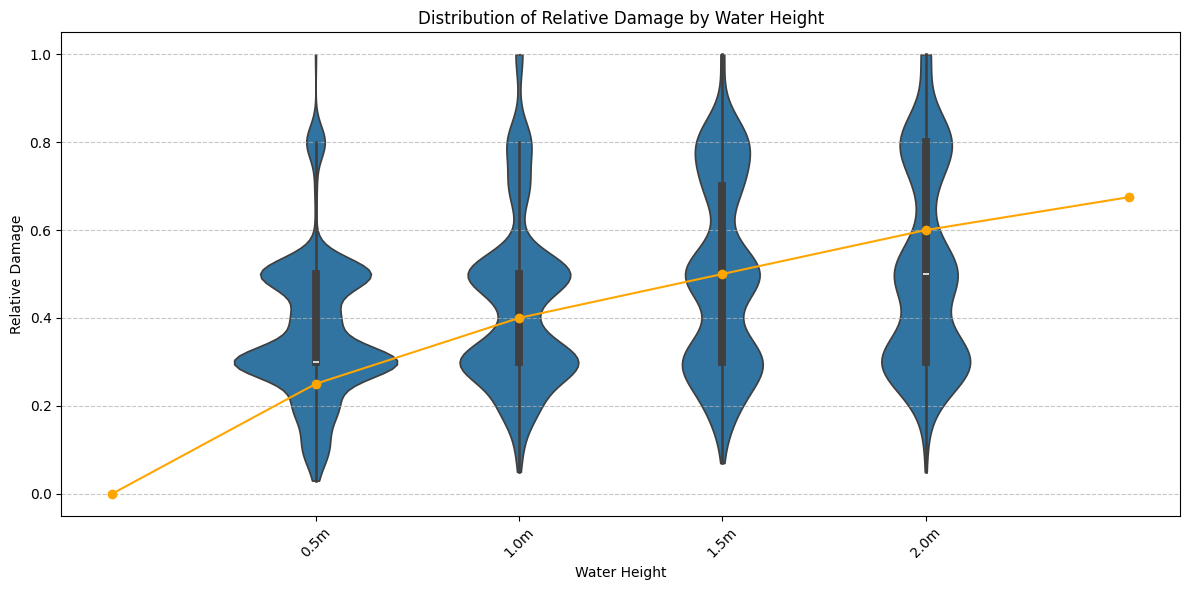

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

_df["Objekt_VisinaVodeM"] = _df["Objekt_VisinaVodeCm"]/100
# Create water height buckets (every 50cm up to 200cm)
bucket_edges = np.arange(0, 2.01, 0.5)
_df["water_height_bucket"] = pd.cut(
    _df["Objekt_VisinaVodeM"], 
    bins=bucket_edges,
    labels=[f"{i}-{i+0.5}m" for i in np.arange(0, 2, 0.5)]
)

# Create the violin plot
plt.figure(figsize=(12, 6))

# Plot violins
sns.violinplot(
    data=_df,
    x="water_height_bucket",
    y="relative_damage",
    cut=0  # limit the violin plot to actual data range
)

# Adjust x-axis to show ticks at the upper bounds of each bucket
plt.gca().set_xticks(range(len(bucket_edges)-1))
plt.gca().set_xticklabels([f"{x}m" for x in bucket_edges[1:]])

# Customize the plot
plt.title("Distribution of Relative Damage by Water Height")
plt.xlabel("Water Height")
plt.ylabel("Relative Damage")
plt.xticks(rotation=45)

# Add grid for better readability
plt.grid(True, axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()

flood_depths = [
    0,
    0.5,
    1,
    1.5,
    2,
    2.5,
    # 3,
    # 4,
    # 5,
    # 6
]
damage_fractions = [
    0.00,
    0.25,
    0.40,
    0.50,
    0.60,
    0.675,
    # 0.75,
    # 0.85,
    # 0.95,
    # 1.00
]
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

def get_damage_fraction(depth):
    """
    Get damage fraction for a given flood depth using polynomial interpolation.
    For depths outside the range, we clamp the values to [0, 1].
    
    Args:
        depth (float): Flood depth in meters
        
    Returns:
        float: Damage fraction between 0 and 1
    """
    # Create interpolation function
    f = interp1d(flood_depths, damage_fractions, kind="linear", bounds_error=False, fill_value=(0, 1))
    return float(f(depth))

# Create points for smooth curve visualization
depths_smooth = np.linspace(0, 2.5, 100)
damage_smooth = [get_damage_fraction(d) for d in depths_smooth]

# # FIX
# positions = range(len(bucket_edges[1:]))  # [0, 1, 2, 3, 4]
# bucket_values = bucket_edges[1:]  # [0.5, 1.0, 1.5, 2.0, 2.5]
# plt.xticks(positions, [f"{x}m" for x in bucket_values], rotation=45)
# new_positions = dict(zip(bucket_values, positions))

# Plot the data and fitted curve
# plt.figure(figsize=(10, 6))
plt.plot([(i - 0.5)*2 for i in flood_depths], damage_fractions, "o", label="Data points", color="orange")
plt.plot([(i - 0.5)*2 for i in depths_smooth], damage_smooth, "-", label="Cubic interpolation", color="orange")

plt.show()

In [102]:
get_damage_fraction(2.5)

0.675

In [88]:
damage_fractions

[0.0, 0.25, 0.4, 0.5, 0.6, 0.75, 0.85]

In [89]:
flood_depths

[0, 0.5, 1, 1.5, 2, 3, 4]

In [17]:
_df[
    _df["predicted_si"]==0
].shape

KeyError: 'predicted_si'

In [17]:
_df[
    _df["predicted_si"]>0
].shape

(3510, 13)

In [25]:
_df = _df[
    _df["Objekt_VisinaVodeCm"].notna()
]

In [27]:
_df["measured_depth"] = _df["Objekt_VisinaVodeCm"]/100

# Export

In [29]:
# Export all cols but "gps_point"
_df.to_excel(os.path.join("../data/predicted_flood_depths.xlsx"), index=False)